Fitting basic ARIMA(2,1,2)...
Fitting optimized SARIMA(1,1,1)x(1,1,1,24)...


/home/sage/sage/local/var/lib/sage/venv-python3.12.5/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/sage/sage/local/var/lib/sage/venv-python3.12.5/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/sage/sage/local/var/lib/sage/venv-python3.12.5/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/sage/sage/local/var/lib/sage/venv-python3.12.5/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: Val


📊 Basic ARIMA(2,1,2):
MAE: 532.76 USD
RMSE: 688.01 USD

📊 Optimized SARIMA(1,1,1)x(1,1,1,24):
MAE: 1246.68 USD
RMSE: 1423.77 USD


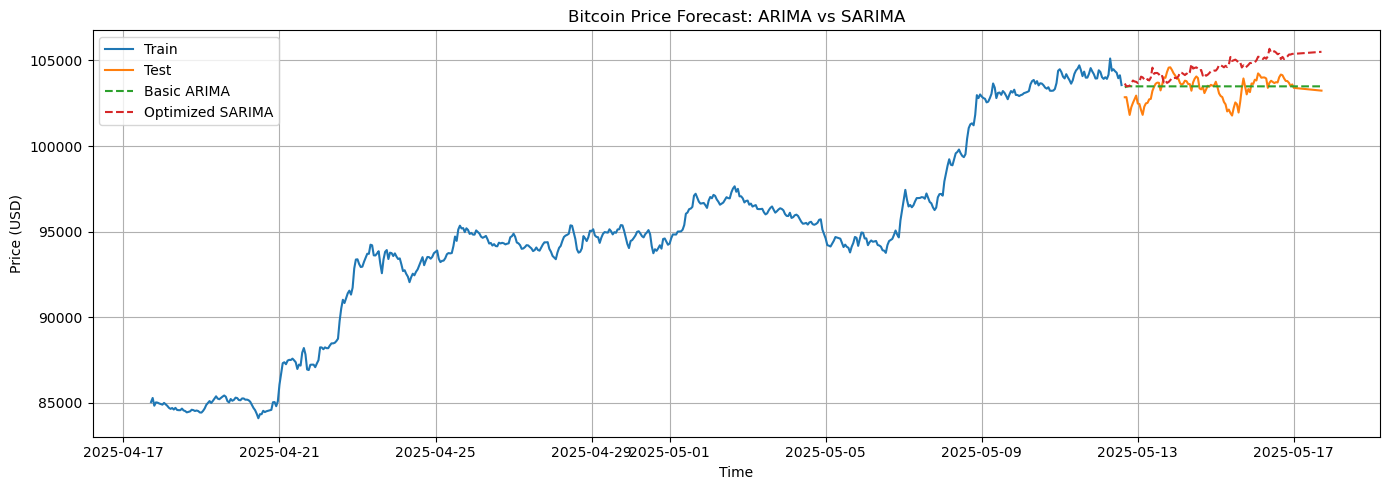

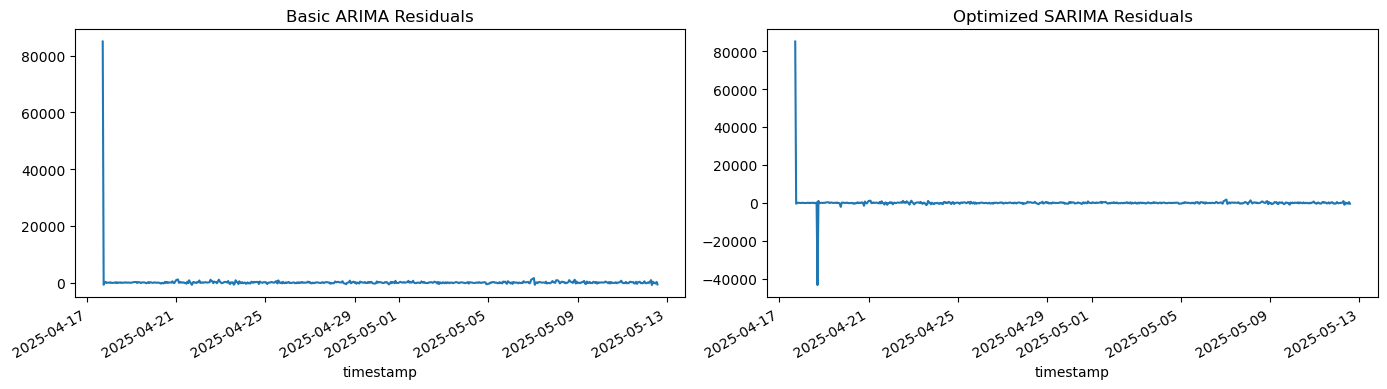

✅ Forecast comparison saved.


In [4]:
# 07_arima_forecasting.ipynb
# Compare simple ARIMA with optimized SARIMA using residual analysis and performance metrics

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Patch for sklearn compatibility
import sklearn.utils.validation
if hasattr(sklearn.utils.validation, 'force_all_finite'):
    sklearn.utils.validation.ensure_all_finite = sklearn.utils.validation.force_all_finite

# --- 1. Load and Prepare Data ---
df = pd.read_csv("../data/bitcoin_timeseries.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp').sort_index()

# Resample to hourly average and filter outliers
df_hourly = df['price_usd'].resample('1h').mean().dropna()
df_hourly = df_hourly[(df_hourly - df_hourly.rolling(24).mean()).abs() < 3 * df_hourly.rolling(24).std()]
df_hourly = df_hourly.dropna()

# Use last 30 days
days_to_use = 30
cutoff = df_hourly.index.max() - pd.Timedelta(days=days_to_use)
df_hourly = df_hourly[df_hourly.index >= cutoff]

# --- 2. Train-Test Split ---
train_size = int(len(df_hourly) * 0.85)
train, test = df_hourly.iloc[:train_size], df_hourly.iloc[train_size:]

# --- 3. Fit Basic ARIMA(2,1,2) ---
print("Fitting basic ARIMA(2,1,2)...")
basic_arima_model = ARIMA(train, order=(2,1,2)).fit()
basic_forecast = basic_arima_model.forecast(steps=len(test))

# --- 4. Fit Optimized SARIMA ---
print("Fitting optimized SARIMA(1,1,1)x(1,1,1,24)...")
opt_sarima_model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,24)).fit(disp=False)
opt_forecast = opt_sarima_model.forecast(steps=len(test))

# --- 5. Evaluate ---
def evaluate(true, pred, label):
    mae = mean_absolute_error(true, pred)
    rmse = mean_squared_error(true, pred) ** 0.5
    print(f"\n📊 {label}:")
    print(f"MAE: {mae:.2f} USD")
    print(f"RMSE: {rmse:.2f} USD")
    return mae, rmse

evaluate(test, basic_forecast, "Basic ARIMA(2,1,2)")
evaluate(test, opt_forecast, "Optimized SARIMA(1,1,1)x(1,1,1,24)")

# --- 6. Plot Forecast Comparison ---
plt.figure(figsize=(14, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, basic_forecast, label='Basic ARIMA', linestyle='--')
plt.plot(test.index, opt_forecast, label='Optimized SARIMA', linestyle='--')
plt.title("Bitcoin Price Forecast: ARIMA vs SARIMA")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("../reports/arima_vs_sarima_comparison.png")
plt.show()

# --- 7. Residual Diagnostics ---
resid_basic = basic_arima_model.resid
resid_opt = opt_sarima_model.resid

plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
resid_basic.plot(title="Basic ARIMA Residuals")
plt.subplot(1,2,2)
resid_opt.plot(title="Optimized SARIMA Residuals")
plt.tight_layout()
plt.savefig("../reports/arima_sarima_residuals.png")
plt.show()

# --- 8. Save Forecasts ---
df_forecast = pd.DataFrame({
    'timestamp': test.index,
    'actual_price': test.values,
    'basic_arima_predicted': basic_forecast,
    'optimized_sarima_predicted': opt_forecast
})
df_forecast.to_csv("../data/bitcoin_forecast_comparison.csv", index=False)
print("✅ Forecast comparison saved.")


In [3]:
from datetime import timedelta

# Get last timestamp from the training data
last_timestamp = train.index[-1]

# Compute forecast horizon
forecast_horizon = len(forecast_arima)  # also matches sarima

# Generate forecast timestamps
forecast_index = [last_timestamp + timedelta(hours=i) for i in range(1, forecast_horizon + 1)]

# Create and save comparison DataFrame
df_comparison = pd.DataFrame({
    'timestamp': forecast_index,
    'arima_pred': list(forecast_arima),
    'sarima_pred': list(forecast_sarima)
})
df_comparison.to_csv('../reports/arima_vs_sarima_forecast.csv', index=False)

NameError: name 'forecast_arima' is not defined